/Users/samnmercado/Documents/AIM/Sem 7/7 DASCI 270 ML Ops/HW1 Stocks Data/solids/data_preprocessing.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Date'] = pd.to_datetime(data['Date'])


Output of read_and_clean_data:
           Date  Dow Jones (^DJI)  Nasdaq (^IXIC)  S&P500 (^GSPC)  \
2605 2003-12-30       10425.04004     2009.880005     1109.640015   
2608 2004-01-05       10544.07031     2047.359985     1122.219971   
2609 2004-01-06       10538.66016     2057.370117     1123.670044   
2610 2004-01-07       10529.03027     2077.679932     1126.329956   
2611 2004-01-08       10592.44043     2100.250000     1131.920044   

      NYSE Composite (^NYA)  Russell 2000 (^RUT)  CBOE Volitility (^VIX)  \
2605            6443.600098           565.469971                   17.68   
2608            6534.580078           568.919983                   17.49   
2609            6541.149902           569.890015                   16.73   
2610            6525.299805           574.619995                   15.50   
2611            6569.319824           579.619995                   15.61   

      DAX Index (^GDAXI)  FTSE 100 (^FTSE)  Hang Seng Index (^HSI)  ...  \
2605         3965.1599

2025/02/25 00:58:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run delightful-bug-190 at: http://localhost:5001/#/experiments/1/runs/ca8c1d2951584afda57be606921507a0
🧪 View experiment at: http://localhost:5001/#/experiments/1
MLflow run completed. Check the MLflow UI for details.


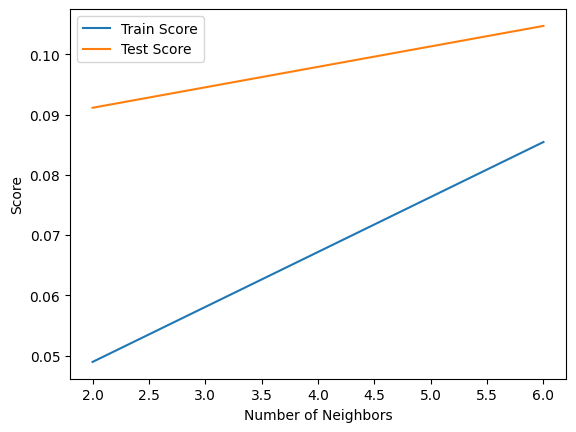

In [ ]:
# Import necessary libraries
import pandas as pd
import mlflow
import mlflow.sklearn
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
import matplotlib.pyplot as plt
from solids.data_preprocessing import read_and_clean_data
from solids.feature_engineering import create_spreads_and_more

# Set the file path for the data
file_path = 'data/30_yr_stock_market_data.csv'

# Read and clean data
data = read_and_clean_data(file_path)

# Create spreads and more
X, y = create_spreads_and_more(data)

# Set MLflow tracking URI
mlflow.set_tracking_uri("http://localhost:5001")

# Start an MLflow experiment
mlflow.set_experiment("Stock Market Prediction")

# Train k-Nearest Neighbors model and log the experiment
with mlflow.start_run(run_name="kNN") as run:
    Number_trials = 3
    n_neighbors_tuning = (2, 6)
    score_train = []
    score_test = []
    
    for seed in range(Number_trials):
        training_mse = []
        test_mse = []
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        for n_neighbors in n_neighbors_tuning:
            start_time = time.time()  # Time the training process
            knn = KNeighborsRegressor(n_neighbors=n_neighbors).fit(X_train, y_train)
            
            # Calculate Mean Squared Error as a performance metric
            training_mse.append(mean_squared_error(y_train, knn.predict(X_train)))
            test_mse.append(mean_squared_error(y_test, knn.predict(X_test)))
            
            run_time = time.time() - start_time
        
        score_train.append(training_mse)
        score_test.append(test_mse)

    train_score = np.mean(np.sqrt(score_train), axis=0)
    test_score = np.mean(np.sqrt(score_test), axis=0)
    best_index = np.argmin(test_score)
    
    best_knn = KNeighborsRegressor(n_neighbors=n_neighbors_tuning[best_index]).fit(X_train, y_train)
    
    # Log the model and metrics to MLflow
    mlflow.sklearn.log_model(best_knn, "kNN_model")
    mlflow.log_param("n_neighbors", n_neighbors_tuning[best_index])
    mlflow.log_metric("train_score", train_score[best_index])
    mlflow.log_metric("test_score", test_score[best_index])
    mlflow.log_metric("run_time", run_time)
    
    # Log artifacts (e.g., plots, data)
    plt.figure()
    plt.plot(n_neighbors_tuning, train_score, label='Train Score')
    plt.plot(n_neighbors_tuning, test_score, label='Test Score')
    plt.xlabel('Number of Neighbors')
    plt.ylabel('Score')
    plt.legend()
    plt.savefig("knn_scores.png")
    mlflow.log_artifact("knn_scores.png")

# Train Gradient Boosting Machine model and log the experiment
with mlflow.start_run(run_name="GBM") as run:
    Number_trials = 3
    n_estimators_tuning = (50, 100)
    score_train = []
    score_test = []
    
    for seed in range(Number_trials):
        training_mse = []
        test_mse = []
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        for n_estimators in n_estimators_tuning:
            start_time = time.time()  # Time the training process
            gbm = GradientBoostingRegressor(n_estimators=n_estimators).fit(X_train, y_train)
            
            # Calculate Mean Squared Error as a performance metric
            training_mse.append(mean_squared_error(y_train, gbm.predict(X_train)))
            test_mse.append(mean_squared_error(y_test, gbm.predict(X_test)))
            
            run_time = time.time() - start_time
        
        score_train.append(training_mse)
        score_test.append(test_mse)

    train_score = np.mean(np.sqrt(score_train), axis=0)
    test_score = np.mean(np.sqrt(score_test), axis=0)
    best_index = np.argmin(test_score)
    
    best_gbm = GradientBoostingRegressor(n_estimators=n_estimators_tuning[best_index]).fit(X_train, y_train)
    
    # Log the model and metrics to MLflow
    mlflow.sklearn.log_model(best_gbm, "GBM_model")
    mlflow.log_param("n_estimators", n_estimators_tuning[best_index])
    mlflow.log_metric("train_score", train_score[best_index])
    mlflow.log_metric("test_score", test_score[best_index])
    mlflow.log_metric("run_time", run_time)
    
    # Log artifacts (e.g., plots, data)
    plt.figure()
    plt.plot(n_estimators_tuning, train_score, label='Train Score')
    plt.plot(n_estimators_tuning, test_score, label='Test Score')
    plt.xlabel('Number of Estimators')
    plt.ylabel('Score')
    plt.legend()
    plt.savefig("gbm_scores.png")
    mlflow.log_artifact("gbm_scores.png")

# Train Random Forest model and log the experiment
with mlflow.start_run(run_name="RF") as run:
    Number_trials = 3
    n_estimators_tuning = (50, 100)
    score_train = []
    score_test = []
    
    for seed in range(Number_trials):
        training_mse = []
        test_mse = []
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
        for n_estimators in n_estimators_tuning:
            start_time = time.time()  # Time the training process
            rf = RandomForestRegressor(n_estimators=n_estimators).fit(X_train, y_train)
            
            # Calculate Mean Squared Error as a performance metric
            training_mse.append(mean_squared_error(y_train, rf.predict(X_train)))
            test_mse.append(mean_squared_error(y_test, rf.predict(X_test)))
            
            run_time = time.time() - start_time
        
        score_train.append(training_mse)
        score_test.append(test_mse)

    train_score = np.mean(np.sqrt(score_train), axis=0)
    test_score = np.mean(np.sqrt(score_test), axis=0)
    best_index = np.argmin(test_score)
    
    best_rf = RandomForestRegressor(n_estimators=n_estimators_tuning[best_index]).fit(X_train, y_train)
    
    # Log the model and metrics to MLflow
    mlflow.sklearn.log_model(best_rf, "RF_model")
    mlflow.log_param("n_estimators", n_estimators_tuning[best_index])
    mlflow.log_metric("train_score", train_score[best_index])
    mlflow.log_metric("test_score", test_score[best_index])
    mlflow.log_metric("run_time", run_time)
    
    # Log artifacts (e.g., plots, data)
    plt.figure()
    plt.plot(n_estimators_tuning, train_score, label='Train Score')
    plt.plot(n_estimators_tuning, test_score, label='Test Score')
    plt.xlabel('Number of Estimators')
    plt.ylabel('Score')
    plt.legend()
    plt.savefig("rf_scores.png")
    mlflow.log_artifact("rf_scores.png")

print("MLflow runs completed. Check the MLflow UI for details.")